In [1]:
import numpy as np
import jax
import jax.numpy as jnp
from jax import jacfwd
from jax import jit
from jax import vmap
import emcee
import h5py
import corner
import matplotlib.pyplot as plt
import corner
import VBMicrolensing
VBM = VBMicrolensing.VBMicrolensing()
import tqdm
import math
import sys
import multiprocessing
sys.path.append("/moao38_7/nunota/gapmoe/src/gapmoe/")
from gapmoe import gapmoe
import EarthMotion
import parametrics
JD0 = 2450000
from emcee.autocorr import integrated_time
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import corner


import jax
import jax.numpy as jnp
from jax import jacfwd
from jax import jit
from jax import vmap
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib as mpl
from matplotlib.patches import Patch
import arviz as az

import logging
logging.getLogger("emcee.autocorr").setLevel(logging.ERROR)

from matplotlib.lines import Line2D

tref = 10063.874
coords = "17:57:38.03 -28:38:28.53"

VBM.t0_par = tref+JD0
VBM.parallaxsystem = 1
VBM.SetObjectCoordinates(coords)

RA_str,Dec_str = "17:57:38.03","-28:38:28.53"
RA_deg = EarthMotion.hms_string_to_degrees(RA_str)
Dec_deg = EarthMotion.dms_string_to_degrees(Dec_str)
vEarth = EarthMotion.calc_vEarth(tref,RA_deg,Dec_deg)

gapmoe_model = gapmoe(RA_deg,Dec_deg)
gapmoe_model.set_data()


In [2]:
@jit
def lightcurve_to_physical(theta,thS,DS,vEarth, G = 2.959122082855911e-4, KAPPA = 8.1429):
    # G [AU^3 / (Msun * day^2)] , KAPPA [mas / Msun]
    t0 = theta[0]
    tE     = theta[1]
    u0 = theta[2]
    rho    = theta[3]
    q = theta[4]
    s      = theta[5]
    alpha = theta[6]
    piEN   = theta[7]
    piEE   = theta[8]
    vEarth_N, vEarthE = vEarth
    
    G = 2.959122082855911e-4 # [AU^3 / (Msun * day^2)]
    KAPPA = 8.1429 # [mas / Msun]

    piE = jnp.sqrt(piEN**2 + piEE**2)

    thE = thS / rho #mas
    ML = thE / KAPPA / piE #Msun
    murel_geo = thE / tE * 365.25 # mas / year
    murel_N_geo = murel_geo * piEN / piE # mas / year
    murel_E_geo = murel_geo * piEE / piE # mas / year

    pi_rel = thE * piE
    pi_S = 1 / DS
    pi_L = pi_rel + pi_S
    DL = 1 / pi_L #kpc
    
    murel_N_hel = murel_N_geo + thE * piE * vEarth[0]
    murel_E_hel = murel_E_geo + thE * piE * vEarth[1]

    return  jnp.array([ML, DL, DS, murel_N_hel, murel_E_hel])


In [3]:
from matplotlib import rcParams
rcParams["font.size"] = 15
rcParams["axes.linewidth"] = 3
rcParams['xtick.top'] = True
rcParams['ytick.right'] = True
rcParams['xtick.direction'] = 'in'
rcParams['ytick.direction'] = 'in'
rcParams['xtick.major.size'] = 10
rcParams['xtick.major.width'] = 1.5
rcParams['xtick.minor.size'] = 5
rcParams['xtick.minor.width'] = 1.5
rcParams['ytick.major.size'] = 10
rcParams['ytick.major.width'] = 1.5
rcParams['ytick.minor.size'] = 5
rcParams['ytick.minor.width'] = 1.5

In [4]:
import tempfile
import shutil
import os
def read_chain(path, burnin, thin, flat=True):
    tmpdir = tempfile.mkdtemp()
    tmp_path = os.path.join(tmpdir, "chain_copy.h5")
    shutil.copy2(path, tmp_path)

    try:
        sampler = emcee.backends.HDFBackend(tmp_path, read_only=True)
        chain = sampler.get_chain(flat=flat, discard=burnin, thin=thin)
        blob = sampler.get_blobs(flat=flat, discard=burnin, thin=thin)
        lnprob = sampler.get_log_prob(flat=flat, discard=burnin, thin=thin)
    finally:
        try:
            os.remove(tmp_path)
            os.rmdir(tmpdir)
        except Exception:
            pass

    return chain, lnprob, blob

In [5]:
def calc_tau(arr):
    taus = []
    for pi in range(arr.shape[2]):
        tau_walkers = []
        for w in range(arr.shape[1]):
            chain = arr[:, w, pi]
            tau = emcee.autocorr.integrated_time(chain[:, None], quiet=True)
            tau_walkers.append(tau.item())
        mean_tau = np.mean(tau_walkers)
        taus.append(mean_tau)
        print(f"param[{pi}] mean τ_int over {arr.shape[1]} walkers = {mean_tau:.2f}")

    return max(taus)
    

In [6]:
def weighted_percentile(data, weights, percentiles=[16, 50, 84]):
    """Weighted percentile calculation"""
    sorter = np.argsort(data)
    data_sorted = data[sorter]
    weights_sorted = weights[sorter]
    cumsum = np.cumsum(weights_sorted)
    cumsum /= cumsum[-1]
    return np.interp(np.array(percentiles)/100, cumsum, data_sorted)

t0_true = 10090 - 5       
u0_true = 0.01
q_true = 0.001
alpha_true = np.pi/2 + 1
tE_true = 58.8441
rho_true = 0.000597948
s_true= 1.14543
piEN_true = 0.0635109
piEE_true = 0.0602449
Ds_true = 8.1
thS_true = 0.0001800539

_truths = [t0_true, tE_true,u0_true, rho_true,
                piEN_true, piEE_true,Ds_true]

truths_lc_04 = [t0_true, tE_true,u0_true, rho_true,q_true,s_true,alpha_true,piEN_true, piEE_true]

truths_kep_04 = parametrics.lightcurve_to_physical_single(_truths,thS_true,vEarth)[2:]

In [7]:
truths_kep_04

Array([0.4224334, 6.674832 , 8.1      , 1.3447213, 1.1847007], dtype=float32)

In [8]:

mpl.rc('font', **{'family': 'serif', 'serif': ['Liberation Serif', 'DejaVu Serif']})
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    "font.size": 20,
    "axes.labelsize": 15,
    "axes.titlesize": 18,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "axes.edgecolor": "0.3",
    "axes.linewidth": 1.4,
    "grid.alpha": 0.25,
    "xtick.direction": "in",
    "ytick.direction": "in",
})

In [9]:
label_inds_kep = {"t0": 0, "tE": 1, "u0": 2, "rho": 3, "q": 4, "s": 5, "alpha": 6,
                  "piEN": 7, "piEE": 8, "gamma1": 9, "gamma2": 10, "gamma3": 11,
                  "rs": 12, "as": 13}

label_inds_kep_phys = {"ML": 3, "DL": 4, "DS": 5, "muN": 6, "muE": 7}

In [10]:
def read_chain(path,burnin,thin,flat=True):
    sampler = emcee.backends.HDFBackend(path)
    chain = sampler.get_chain(flat=flat, discard=burnin, thin=thin)
    blob = sampler.get_blobs(flat=flat, discard=burnin, thin=thin) 
    lnprob = sampler.get_log_prob(flat=flat, discard=burnin, thin=thin) 
    return chain, blob,lnprob

names = "wtj          M_L   D_L   D_S          t_E      theta_E         pi_E         pi_EN         pi_EE       mu_rel        mu_Sl        mu_Sb     I_L     K_L iS iL fREM".split()

def load_genulens(path):
    genulens_out = np.genfromtxt(path,names=names)
    wtj = genulens_out["wtj"] / np.sum(genulens_out["wtj"])
    ML_genu = genulens_out["M_L"]
    DL_genu = genulens_out["D_L"] * 1e-3
    DS_genu = genulens_out["D_S"] * 1e-3
    muN_genu = genulens_out["mu_rel"] * genulens_out["pi_EN"] / genulens_out["pi_E"] + genulens_out["theta_E"] * genulens_out["pi_E"]  * vEarth[0]
    muE_genu = genulens_out["mu_rel"] * genulens_out["pi_EE"] / genulens_out["pi_E"] + genulens_out["theta_E"] * genulens_out["pi_E"]  * vEarth[1]

    return np.array(wtj), np.array([ML_genu,DL_genu,DS_genu,muN_genu,muE_genu ]).T

wt, genuout = load_genulens("/moao38_7/nunota/gapmoe/test_result/genout/Ds_prior.dat")

In [11]:
chain_para, blob_para, lnprob_para = read_chain("/moao41_9/nunota/gapmoe/chain_simu08_para.h5",0,100,flat=True)
chain_sta, blob_sta, lnprob_sta = read_chain("/moao41_9/nunota/gapmoe/chain_simu08_sta.h5",0,100,flat=True)

print(np.min(-2*lnprob_para)-np.min(-2*lnprob_sta))

-11.717632051018882


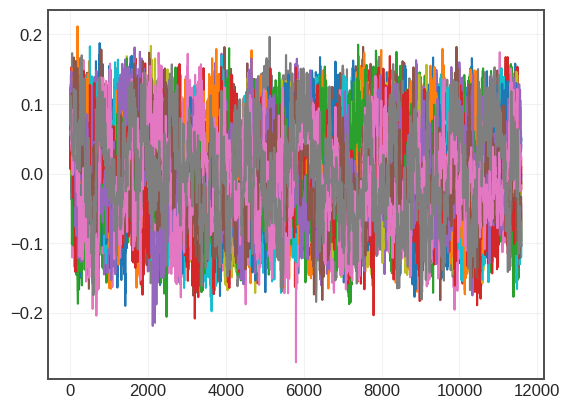

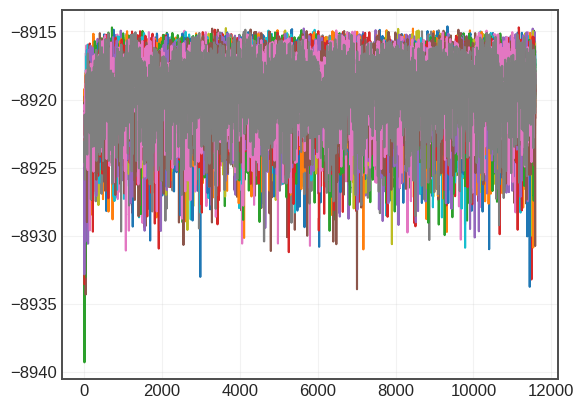

In [12]:
_chain, _blob, _lnprob = read_chain("/moao41_9/nunota/gapmoe/chain_simu08_para.h5",0,1,flat=False)
plt.plot(_chain[:,:,-1])
plt.show()

plt.plot(_lnprob)
plt.show()

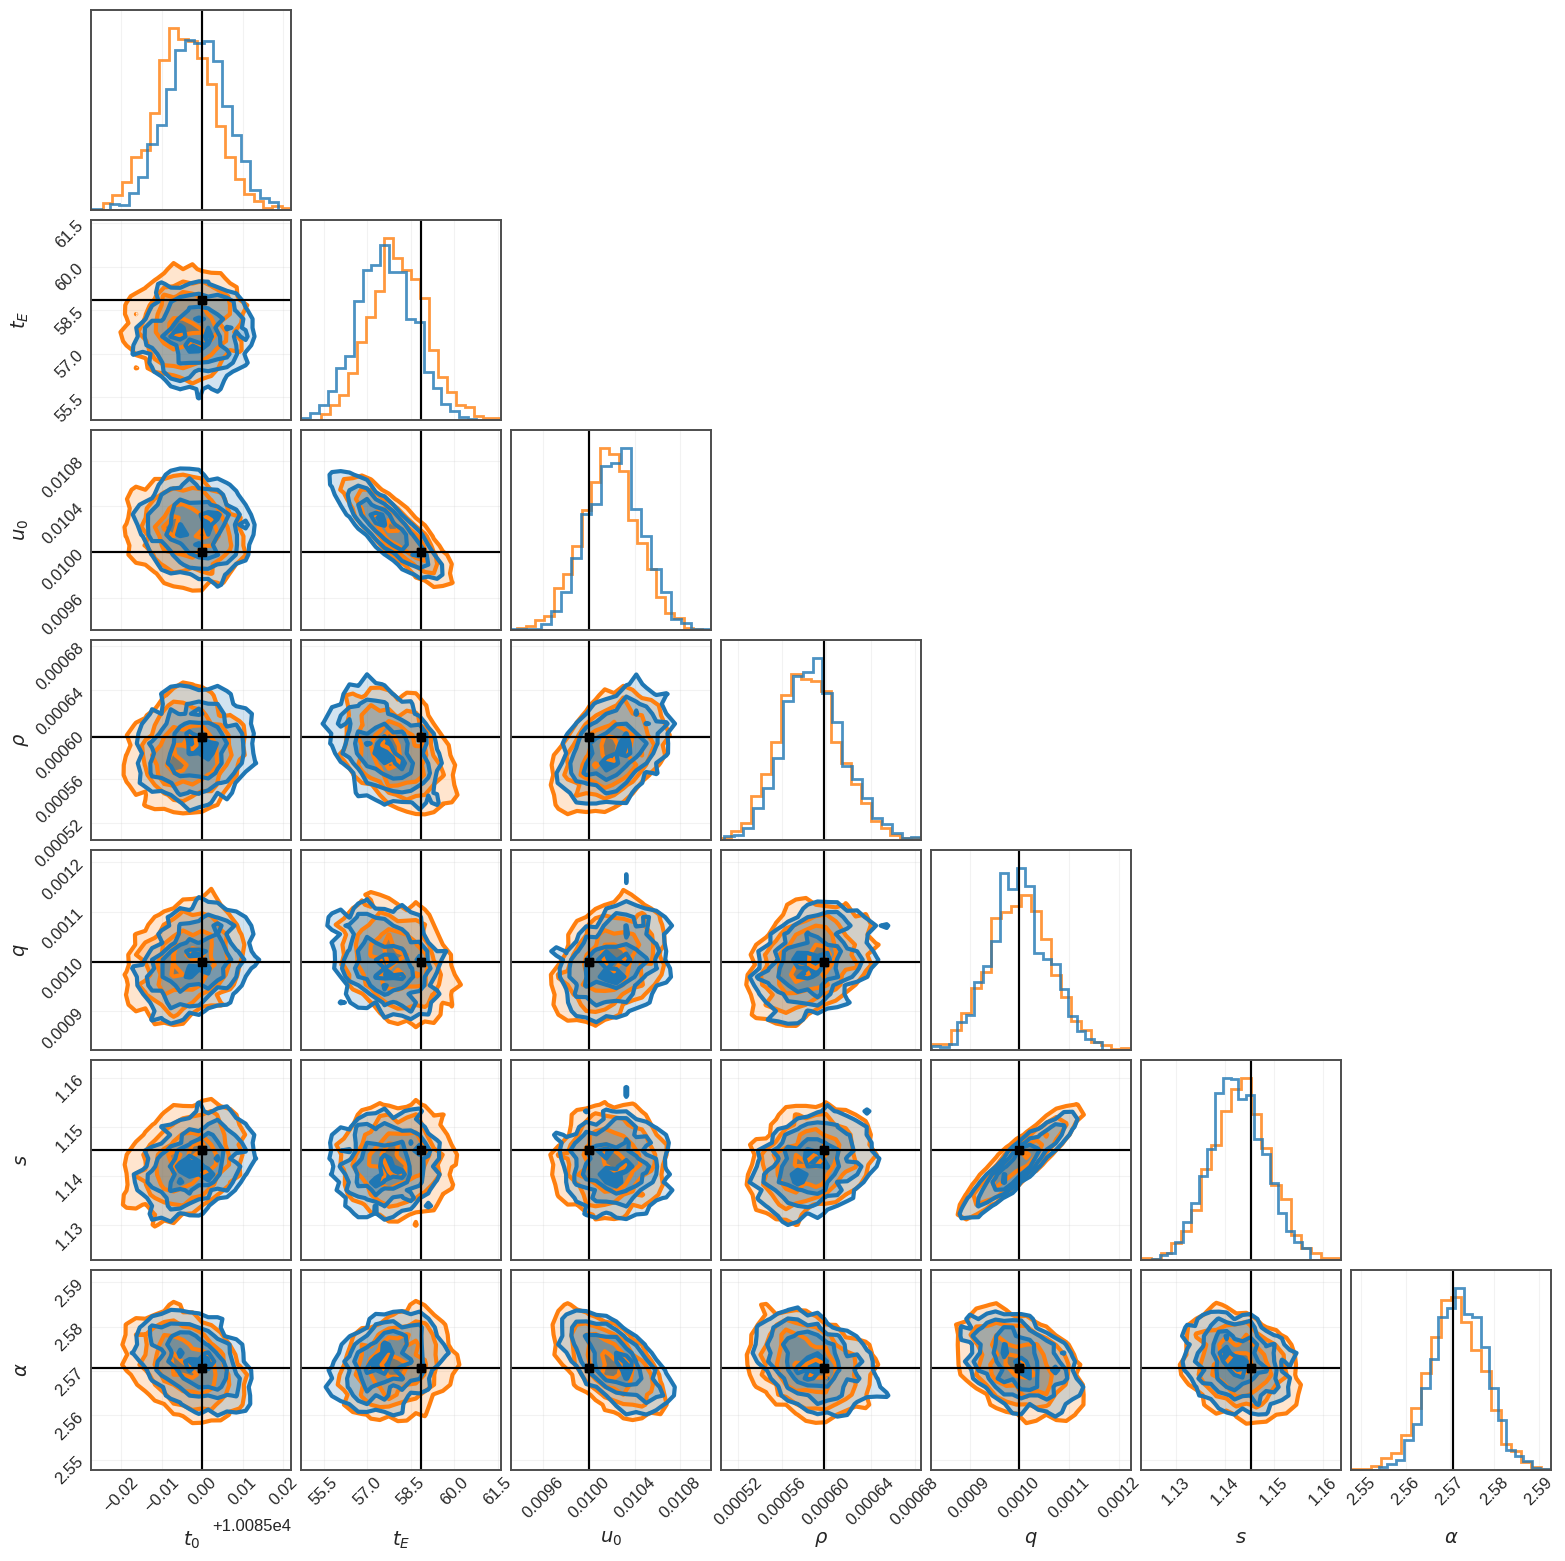

In [13]:
_labels = [
    r"$t_{0}$",
    r"$t_E$",
    r"$u_0$",
    r"$\rho$",
    r"$q$",r"$s$",r"$\alpha$"
]

fig = corner.corner(chain_para[:,:-2],color="C1",labels=_labels,truths=truths_lc_04[:-2],truth_color="k",
    hist_kwargs={"density": True, "linewidth": 2, "alpha": 0.8, "histtype": "step","zorder":2},
    label_kwargs={"fontsize": 14},
    contour_kwargs={"zorder": 2, "linewidths": 3},
    fill_contours=True,
    no_fill_contours=True,
    show_titles=False,
    plot_density=False,
    plot_datapoints=False,
    smooth=.5,)

corner.corner(chain_sta,color="C0",labels=_labels,truths=truths_lc_04[:-2],truth_color="k",fig=fig,
    hist_kwargs={"density": True, "linewidth": 2, "alpha": 0.8, "histtype": "step","zorder":2},
    label_kwargs={"fontsize": 14},
    contour_kwargs={"zorder": 2, "linewidths": 3},
    fill_contours=True,
    no_fill_contours=True,
    show_titles=False,
    plot_density=False,
    plot_datapoints=False,
    smooth=.5,)


handles = [
    Line2D([], [], color="C0", lw=5, label="static"),
    Line2D([], [], color="C1", lw=5, label="parallax"),
]

plt.show()

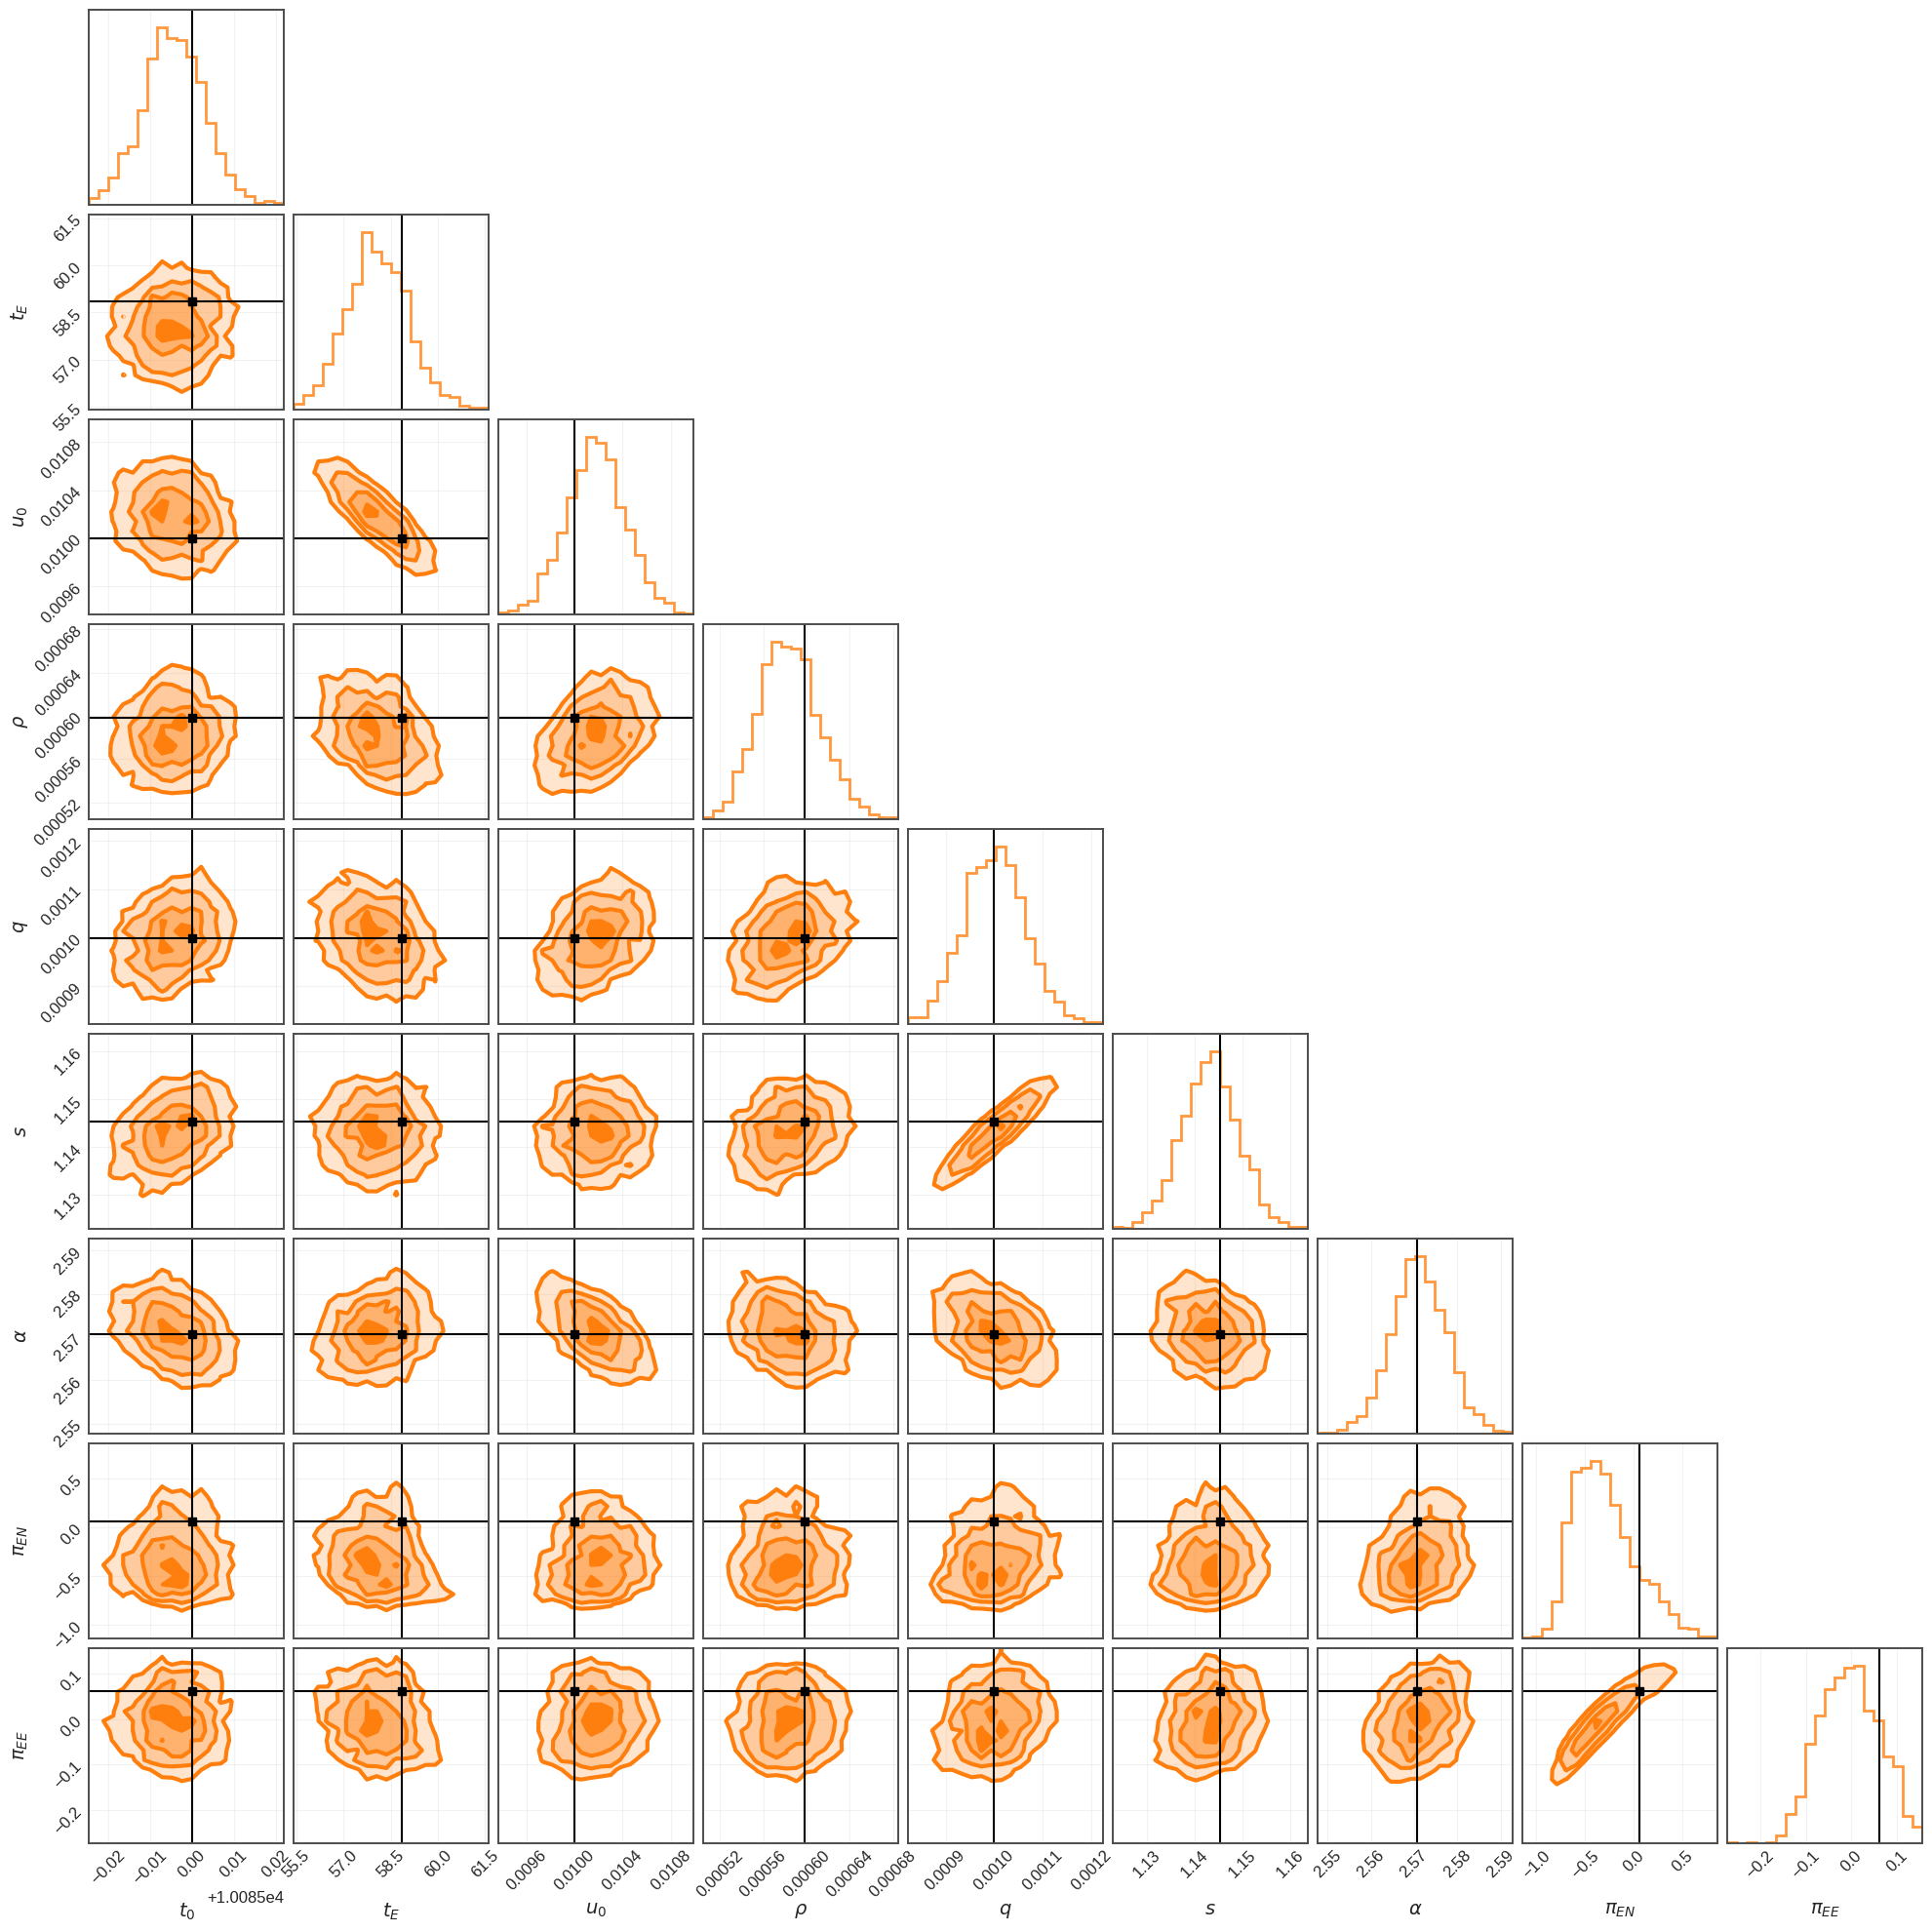

In [14]:
_labels = [
    r"$t_{0}$",
    r"$t_E$",
    r"$u_0$",
    r"$\rho$",
    r"$q$",r"$s$",r"$\alpha$","$\pi_{EN}$","$\pi_{EE}$"
]

fig = corner.corner(chain_para,color="C1",labels=_labels,truths=truths_lc_04,truth_color="k",
    hist_kwargs={"density": True, "linewidth": 2, "alpha": 0.8, "histtype": "step","zorder":2},
    label_kwargs={"fontsize": 14},
    contour_kwargs={"zorder": 2, "linewidths": 3},
    fill_contours=True,
    no_fill_contours=True,
    show_titles=False,
    plot_density=False,
    plot_datapoints=False,
    smooth=.5,)

handles = [
    Line2D([], [], color="C0", lw=5, label="static"),
    Line2D([], [], color="C1", lw=5, label="parallax"),
]

plt.show()

In [15]:
Ds = genuout[:chain_para.shape[0], 2]  # shape: (N,)

_vmap = jax.vmap(
    lambda theta, thS, D_S : lightcurve_to_physical(theta, thS, D_S, vEarth),
    in_axes=(0, 0, 0)  
)

result = np.array(_vmap(chain_para, blob_para, Ds))

In [16]:
bounds = {
#     "tE":    (30, 90),
#     "rho":   (0.00055, 0.00065),
    "tE":    (55, 75),
    "rho":   (1e-4, 1e-3),
    "piEN":  (-3, 3),
    "piEE":  (-3, 3),
}

rng = np.random.default_rng(seed=42)
samples = np.stack([
    rng.uniform(low, high,chain_para.shape[0] )
    for (low, high) in bounds.values()], axis=-1)

uni_chain = chain_para.copy()
uni_chain[:,1] = samples[:,0]
uni_chain[:,3] = samples[:,1]
uni_chain[:,7] = samples[:,2]
uni_chain[:,8] = samples[:,3]

result_prior = np.array(_vmap(uni_chain, blob_para, Ds))

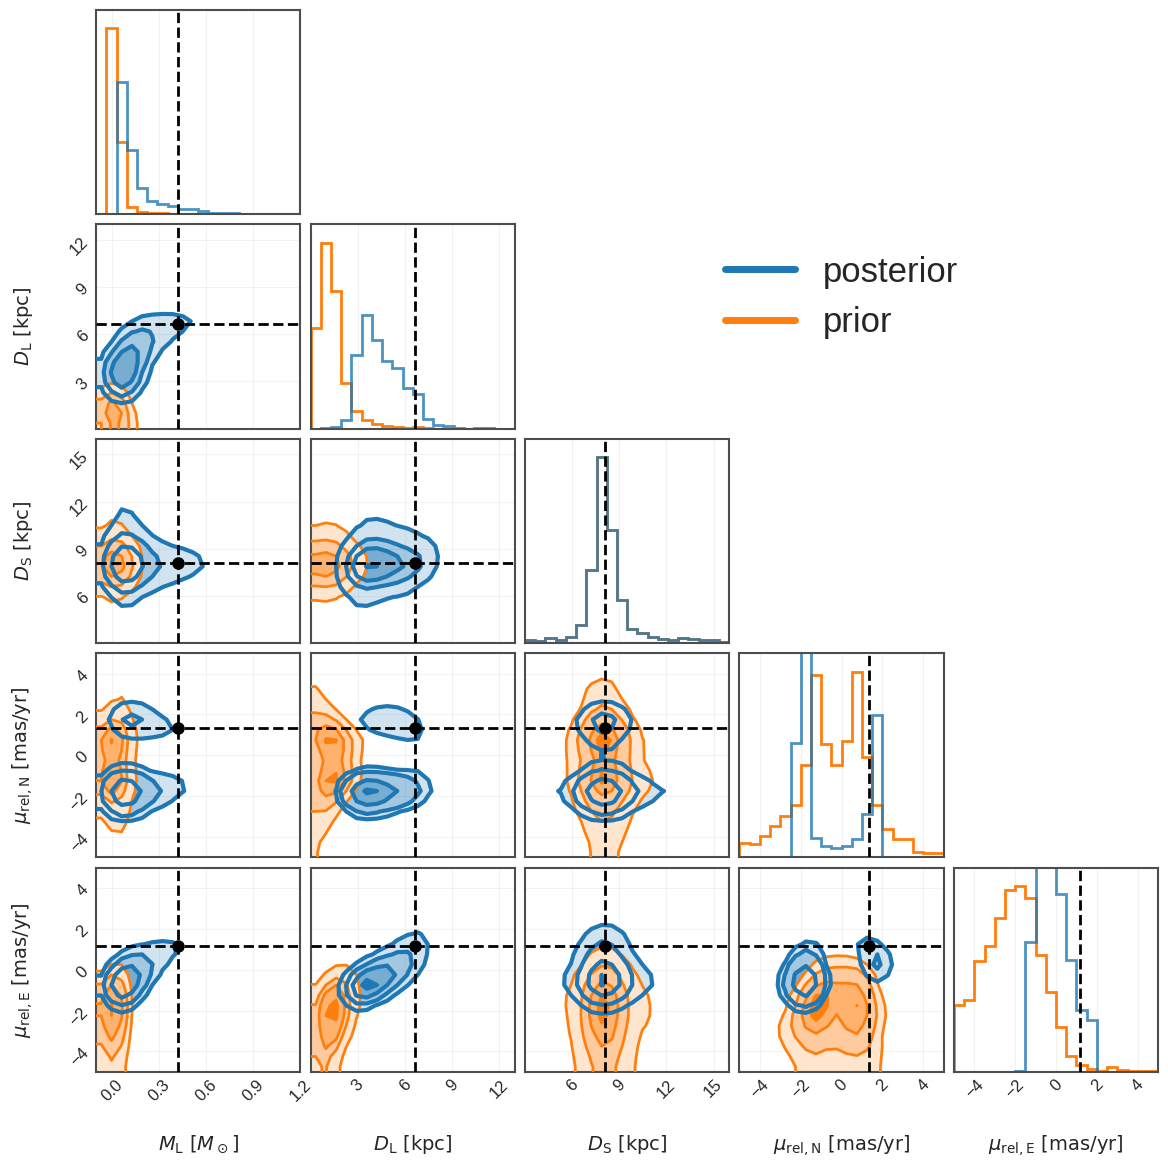

In [17]:
# 物理パラメータのラベル（順番は result / truths_kep_04 に合わせて）
labels_phys = [
    r"$M_{\rm L}\ [{M_\odot}]$",
    r"$D_{\rm L}\ [{\rm kpc}]$",
    r"$D_{\rm S}\ [{\rm kpc}]$",
    r"$\mu_{\rm rel,N}\ [{\rm mas/yr}]$",
    r"$\mu_{\rm rel,E}\ [{\rm mas/yr}]$",
]

# 各パラメータの表示レンジ（さっきの例をそのまま採用）
ranges = [
    (-0.1, 1.2),   # M_L
    (0, 13),       # D_L
    (3, 16),       # D_S
    (-5, 5),       # mu_rel_N
    (-5, 5),       # mu_rel_E
]

# ------------------------
# posterior（result）の corner
# ------------------------
fig = corner.corner(
    result,               # shape: (Nsamples, 5) を想定
    labels=labels_phys,
    range=ranges,
    color="C0",
    hist_kwargs={
        "density": True,
        "linewidth": 2,
        "alpha": 0.8,
        "histtype": "step",
        "zorder": 2,
    },
    label_kwargs={"fontsize": 14},
    contour_kwargs={
        "zorder": 5,
        "linewidths": 3,
    },
    fill_contours=True,
    no_fill_contours=True,   # 塗りつぶし輪郭＋線だけ輪郭
    show_titles=False,
    plot_density=False,
    plot_datapoints=False,smooth=1
)

corner.corner(
    result_prior,        # shape: (Nsamples_prior, 5) を想定
    fig=fig,
    range=ranges,
    color="C1",
    hist_kwargs={
        "density": True,
        "linewidth": 2,
        "alpha": 1.0,
        "histtype": "step",
        "zorder": 1,
    },
    label_kwargs={"fontsize": 14},
    contour_kwargs={
        "zorder": 3,
        "linewidths": 2,
    },
    fill_contours=True,
    show_titles=False,
    plot_density=False,
    plot_datapoints=False,smooth=1
)

ndim = result.shape[1]
axes = np.array(fig.axes).reshape((ndim, ndim))

for i in range(ndim):
    for j in range(ndim):
        ax = axes[i, j]
        ax.minorticks_on()
        ax.tick_params(
            which="both",
            direction="in",
            top=True,
            right=True,
            labelsize=12,
        )
        for spine in ax.spines.values():
            spine.set_linewidth(1.5)

# ------------------------
# 真値ライン（truths_kep_04[:5]）を描く
# ------------------------
truths = truths_kep_04[:5]

# オフダイアゴナル：交点＋縦横の破線
for i in range(1, ndim):
    for j in range(i):
        ax = axes[i, j]
        ax.axhline(truths[i], color="k", linestyle="--", lw=2, zorder=9)
        ax.axvline(truths[j], color="k", linestyle="--", lw=2, zorder=9)
        ax.plot(
            truths[j],
            truths[i],
            "o",
            color="k",
            markersize=8,
            zorder=10,
        )

# 対角成分：縦線だけ
for i in range(ndim):
    ax = axes[i, i]
    ax.axvline(truths[i], color="k", linestyle="--", lw=2, zorder=9)

# ylims = [
#     (0, 13),    # M_L
#     (0, 2),  # D_L
#     (0, 0.6),  # D_S
#     (0, 0.5),  # mu_rel_N
#     (0, 0.55),    # mu_rel_E
# ]

# for i in range(ndim):
#     ax = axes[i, i]
#     ax.set_ylim(ylims[i])

handles = [
    Line2D([], [], color="C0", lw=5, label="posterior"),
    Line2D([], [], color="C1", lw=5, label="prior"),
]

axes[1, -2].legend(
    handles=handles,
    fontsize=25,
    loc="upper center",
    frameon=False,
)

# レイアウト微調整
fig.subplots_adjust(
    left=0.08,
    right=0.98,
    bottom=0.08,
    top=0.98,
    wspace=0.05,
    hspace=0.05,
)

plt.show()


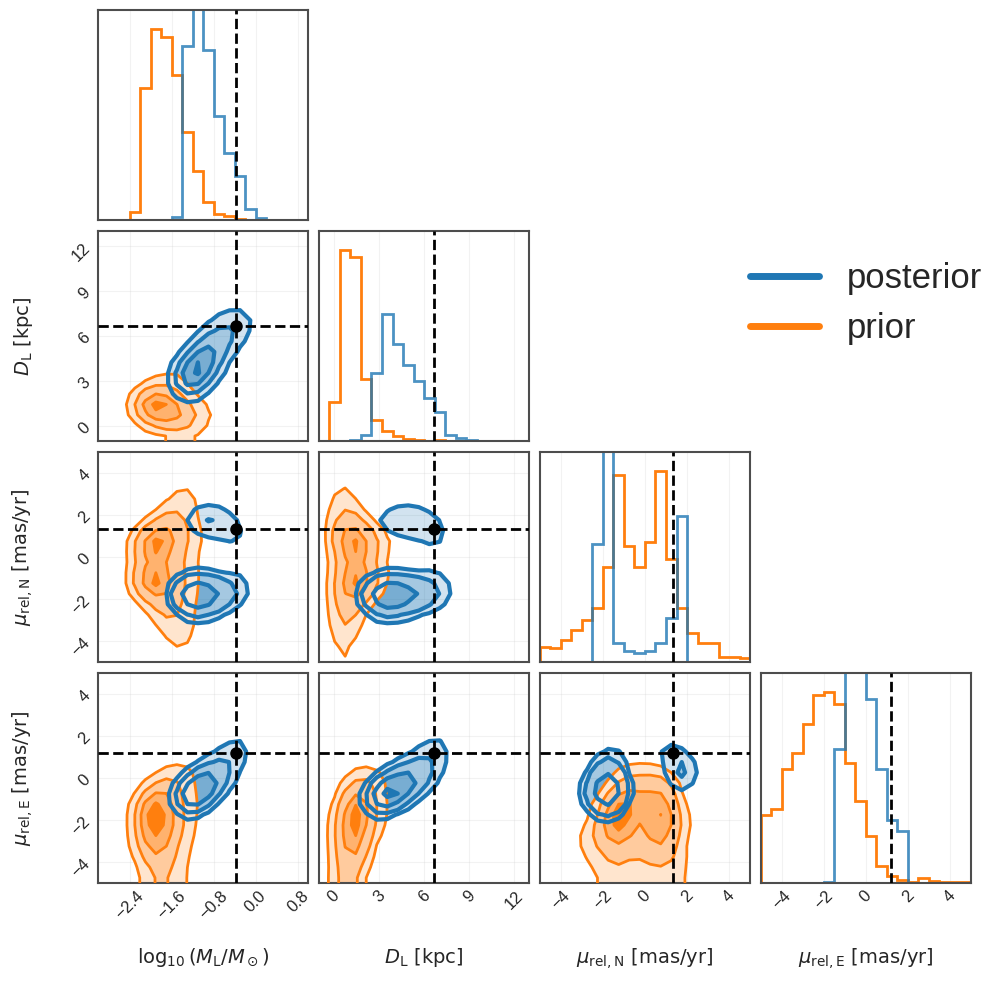

In [18]:
labels_phys = [
    r"$\log_{10} (M_{\rm L} / {M_\odot})$",
    r"$D_{\rm L}\ [{\rm kpc}]$",
    r"$\mu_{\rm rel,N}\ [{\rm mas/yr}]$",
    r"$\mu_{\rm rel,E}\ [{\rm mas/yr}]$",
]

ranges = [
    (-3, 1),
    (-1, 13),
    (-5, 5),
    (-5, 5),
]

idx = [0, 1, 3, 4]
result_plot = result[:, idx].copy()
result_prior_plot = result_prior[:, idx].copy()
truths = np.array(truths_kep_04)[idx].copy()
result_plot = result_plot[np.where((result_plot[:,0]<2)&(result_plot[:,1]<10))]
result_plot[:,0] = np.log10(result_plot[:,0])
result_prior_plot[:,0] = np.log10(result_prior_plot[:,0])
truths[0] = np.log10(truths[0])

fig = corner.corner(
    result_plot,
    labels=labels_phys,
    range=ranges,
    color="C0",
    hist_kwargs={
        "density": True,
        "linewidth": 2,
        "alpha": 0.8,
        "histtype": "step",
        "zorder": 2,
    },
    label_kwargs={"fontsize": 14},
    contour_kwargs={
        "zorder": 5,
        "linewidths": 3,
    },
    fill_contours=True,
    no_fill_contours=True,
    show_titles=False,
    plot_density=False,
    plot_datapoints=False,
    smooth=1,
)

corner.corner(
    result_prior_plot,
    fig=fig,
    range=ranges,
    color="C1",
    hist_kwargs={
        "density": True,
        "linewidth": 2,
        "alpha": 1.0,
        "histtype": "step",
        "zorder": 1,
    },
    contour_kwargs={
        "zorder": 3,
        "linewidths": 2,
    },
    fill_contours=True,
    show_titles=False,
    plot_density=False,
    plot_datapoints=False,
    smooth=1,
)

ndim = result_plot.shape[1]
axes = np.array(fig.axes).reshape((ndim, ndim))

for i in range(ndim):
    for j in range(ndim):
        ax = axes[i, j]
        ax.minorticks_on()
        ax.tick_params(
            which="both",
            direction="in",
            top=True,
            right=True,
            labelsize=12,
        )
        for spine in ax.spines.values():
            spine.set_linewidth(1.5)

for i in range(1, ndim):
    for j in range(i):
        ax = axes[i, j]
        ax.axhline(truths[i], color="k", linestyle="--", lw=2, zorder=9)
        ax.axvline(truths[j], color="k", linestyle="--", lw=2, zorder=9)
        ax.plot(truths[j], truths[i], "o", color="k", ms=8, zorder=10)

for i in range(ndim):
    ax = axes[i, i]
    ax.axvline(truths[i], color="k", linestyle="--", lw=2, zorder=9)

# ylims = [
#     (0, 13),
#     (0, 2),
#     (0, 0.5),
#     (0, 0.55),
# ]

# for i in range(ndim):
#     axes[i, i].set_ylim(ylims[i])

handles = [
    Line2D([], [], color="C0", lw=5, label="posterior"),
    Line2D([], [], color="C1", lw=5, label="prior"),
]

axes[1, -1].legend(
    handles=handles,
    fontsize=25,
    loc="upper center",
    frameon=False,
)

fig.subplots_adjust(
    left=0.08,
    right=0.98,
    bottom=0.08,
    top=0.98,
    wspace=0.05,
    hspace=0.05,
)

plt.show()


(array([305., 354., 364., 357., 317., 248., 100.,  22.,   2.,   1.]),
 array([0.02388009, 0.1385976 , 0.25331512, 0.36803264, 0.48275015,
        0.59746767, 0.71218519, 0.8269027 , 0.94162022, 1.05633774,
        1.17105525]),
 <BarContainer object of 10 artists>)

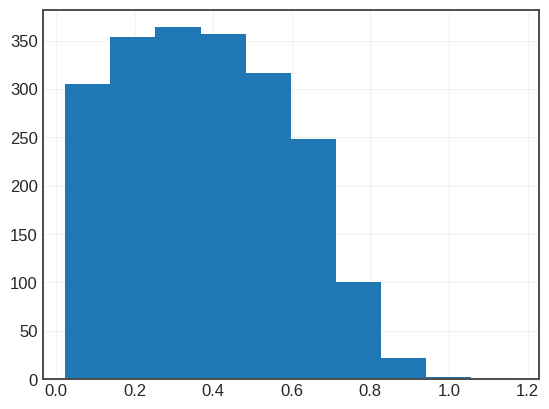

In [19]:
plt.hist(np.sqrt(chain_para[:,7]**2 + chain_para[:,8]**2))